# Clustering using Kmeans with PCA and UMAP

create a general portfolio for nifty50 for clustering

In [15]:
import yfinance as yf
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

import umap
import matplotlib.pyplot as plt

In [3]:
tickers = [
"RELIANCE.NS","TCS.NS","HDFCBANK.NS","INFY.NS","ICICIBANK.NS",
"HINDUNILVR.NS","ITC.NS","SBIN.NS","BHARTIARTL.NS","KOTAKBANK.NS",
"LT.NS","HCLTECH.NS","AXISBANK.NS","ASIANPAINT.NS","MARUTI.NS",
"SUNPHARMA.NS","TITAN.NS","ULTRACEMCO.NS","NESTLEIND.NS","BAJFINANCE.NS",
"WIPRO.NS","NTPC.NS","ONGC.NS","POWERGRID.NS","JSWSTEEL.NS",
"TATASTEEL.NS","HINDALCO.NS","TECHM.NS","ADANIENT.NS","ADANIPORTS.NS",
"BAJAJFINSV.NS","BRITANNIA.NS","DIVISLAB.NS","DRREDDY.NS","EICHERMOT.NS",
"GRASIM.NS","HEROMOTOCO.NS","INDUSINDBK.NS","SBILIFE.NS","HDFCLIFE.NS",
"COALINDIA.NS","CIPLA.NS","APOLLOHOSP.NS","BAJAJ-AUTO.NS","BPCL.NS",
"UPL.NS","TATACONSUM.NS","SHREECEM.NS","M&M.NS","DMART.NS"
]

In [7]:
# 2. DOWNLOAD DATA
data = yf.download(
    tickers,
    period="1y",
    interval="1d"
)["Close"]

[*********************100%***********************]  50 of 50 completed


In [8]:
data

Ticker,ADANIENT.NS,ADANIPORTS.NS,APOLLOHOSP.NS,ASIANPAINT.NS,AXISBANK.NS,BAJAJ-AUTO.NS,BAJAJFINSV.NS,BAJFINANCE.NS,BHARTIARTL.NS,BPCL.NS,...,SHREECEM.NS,SUNPHARMA.NS,TATACONSUM.NS,TATASTEEL.NS,TCS.NS,TECHM.NS,TITAN.NS,ULTRACEMCO.NS,UPL.NS,WIPRO.NS
Date,,,,,,,,,,,,,,,,,,,,,
2025-03-04,2143.737305,1052.827759,6172.045410,2109.316895,1000.944580,7152.039062,1789.428223,853.329468,1562.289429,234.576828,...,27232.853516,1551.283447,947.527466,136.164566,3414.062988,1446.400757,3039.353271,10304.780273,607.837585,267.687714
2025-03-05,2244.737305,1107.312622,6198.226562,2141.024170,1013.583801,7236.888672,1800.922607,824.780701,1604.833740,240.133392,...,28021.175781,1567.078369,949.760925,142.770508,3428.561768,1494.849121,3077.289062,10398.288086,622.156494,272.563477
2025-03-06,2251.733887,1130.698853,6257.771973,2243.467529,1033.216919,7277.801758,1844.551270,835.926941,1613.412109,248.768585,...,27927.921875,1598.322021,951.101013,147.011612,3481.289795,1461.173340,3111.735352,10427.403320,619.035095,273.328278
2025-03-07,2246.386475,1138.958740,6199.922852,2245.743164,1036.764038,7387.520996,1844.401489,835.295776,1617.180542,245.220673,...,27851.736328,1593.667725,954.972290,148.106079,3490.568848,1450.385620,3070.110596,10515.744141,624.138367,272.276642
2025-03-10,2227.196045,1137.366577,6133.595703,2254.251465,1034.965454,7200.900879,1839.453735,829.143738,1617.428467,241.156464,...,27750.671875,1595.846191,950.257263,147.607712,3469.738770,1445.040161,3017.718262,10453.835938,609.868958,268.548157
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-25,2231.699951,1528.699951,7783.000000,2416.399902,1403.000000,10097.000000,2049.300049,1021.049988,1913.400024,381.049988,...,26865.000000,1764.199951,1172.300049,214.639999,2629.300049,1361.800049,4325.000000,13041.000000,626.200012,201.919998
2026-02-26,2216.399902,1550.599976,7775.000000,2394.899902,1395.500000,10110.000000,2041.300049,1012.950012,1929.599976,386.000000,...,26745.000000,1785.699951,1159.500000,215.520004,2647.699951,1361.800049,4342.600098,12937.000000,640.450012,201.080002
2026-02-27,2161.800049,1521.000000,7821.500000,2376.199951,1383.900024,9972.500000,1993.400024,995.900024,1879.300049,385.399994,...,26075.000000,1737.000000,1141.000000,212.330002,2637.399902,1357.800049,4327.500000,12677.000000,637.400024,200.960007


In [9]:
data = data.dropna(axis=1)

In [10]:
# 3. CALCULATE RETURNS
returns = data.pct_change().dropna()

# Transpose for clustering
# Each row = stock
# Each column = time
X = returns.T

In [28]:
X

Date,2025-03-05,2025-03-06,2025-03-07,2025-03-10,2025-03-11,2025-03-12,2025-03-13,2025-03-17,2025-03-18,2025-03-19,...,2026-02-18,2026-02-19,2026-02-20,2026-02-23,2026-02-24,2026-02-25,2026-02-26,2026-02-27,2026-03-02,2026-03-04
Ticker,,,,,,,,,,,,,,,,,,,,,
ADANIENT.NS,0.047114,0.003117,-0.002375,-0.008543,0.010008,-0.003910,-0.009234,0.014227,0.000000,0.029276,...,-0.014133,-0.024647,0.001901,0.013976,-0.003651,0.022309,-0.006856,-0.024634,-0.017208,-0.025981
ADANIPORTS.NS,0.051751,0.021120,0.007305,-0.001398,-0.006912,-0.005903,-0.008065,0.016038,0.000000,0.031966,...,-0.009896,-0.024181,-0.001189,0.029309,-0.000257,-0.017166,0.014326,-0.019089,-0.033333,-0.027069
APOLLOHOSP.NS,0.004242,0.009607,-0.009244,-0.010698,-0.002407,0.001459,-0.006201,0.008353,0.000000,0.044001,...,0.006051,-0.007192,0.003029,0.010177,0.003575,0.008095,-0.001028,0.005981,-0.003836,-0.037669
ASIANPAINT.NS,0.015032,0.047848,0.001014,0.003789,0.003862,-0.015782,-0.008884,-0.005266,0.000000,0.027551,...,-0.002174,-0.012870,0.011371,0.000659,-0.006832,0.001367,-0.008898,-0.007808,-0.029080,-0.016471
AXISBANK.NS,0.012627,0.019370,0.003433,-0.001735,-0.009847,-0.014089,-0.000989,0.023708,0.000000,0.017309,...,0.014589,-0.014815,0.008625,0.013447,0.000649,0.011098,-0.005346,-0.008312,-0.008382,-0.028638
BAJAJ-AUTO.NS,0.011864,0.005653,0.015076,-0.025262,0.015785,0.002013,-0.001377,-0.002485,0.000000,0.031499,...,0.015621,-0.025150,0.008017,0.010044,-0.007723,0.027266,0.001288,-0.013600,-0.019704,-0.020407
BAJAJFINSV.NS,0.006423,0.024226,-0.000081,-0.002683,-0.018991,0.007782,-0.006595,0.035492,0.000000,-0.015682,...,0.007924,-0.013297,0.012443,-0.003352,-0.004046,0.002936,-0.003904,-0.023465,-0.025835,-0.027911
BAJFINANCE.NS,-0.033456,0.013514,-0.000755,-0.007365,-0.000258,0.017265,-0.007543,0.018990,0.000000,0.017627,...,0.009515,-0.006593,0.012930,0.000777,-0.007226,-0.002442,-0.007933,-0.016832,-0.017723,-0.028674
BHARTIARTL.NS,0.027232,0.005345,0.002336,0.000153,0.019620,-0.012087,-0.006300,0.004074,0.000000,-0.001220,...,0.000742,-0.016421,-0.005632,0.010064,-0.028188,-0.014219,0.008467,-0.026068,-0.003246,0.000961


In [11]:
# 4. NORMALIZE DATA

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [12]:
# 5. PCA DIMENSION REDUCTION

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("Explained variance:", pca.explained_variance_ratio_)

Explained variance: [0.08429959 0.06985248]


In [16]:
# 6. UMAP DIMENSION REDUCTION

umap_model = umap.UMAP(
    n_neighbors=10,
    min_dist=0.1,
    random_state=42
)

X_umap = umap_model.fit_transform(X_scaled)

C:\Users\Hexi\Miniconda3\envs\dds3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [22]:
# 7. KMEANS CLUSTERING

kmeans = KMeans(n_clusters=6, random_state=42)

clusters = kmeans.fit_predict(X_scaled)

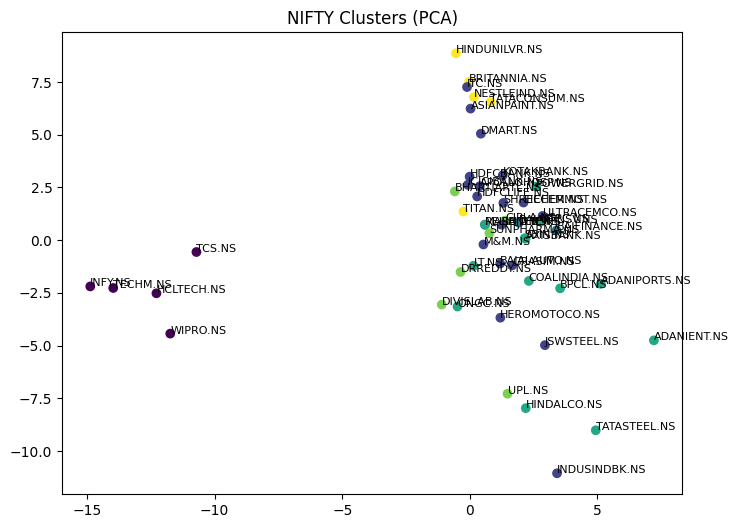

In [23]:
# 8. VISUALIZE PCA CLUSTERS

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=clusters
)

for i, ticker in enumerate(X.index):
    plt.text(X_pca[i,0], X_pca[i,1], ticker, fontsize=8)

plt.title("NIFTY Clusters (PCA)")
plt.show()

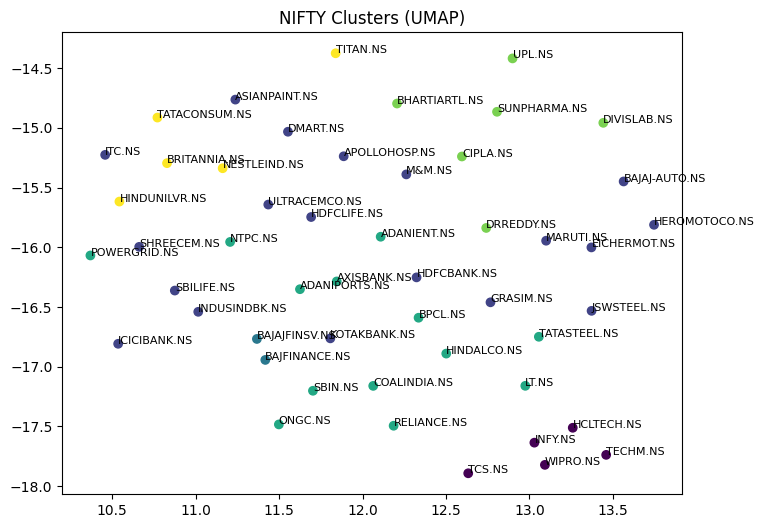

In [24]:
# 9. VISUALIZE UMAP CLUSTERS

plt.figure(figsize=(8,6))

plt.scatter(
    X_umap[:,0],
    X_umap[:,1],
    c=clusters
)

for i, ticker in enumerate(X.index):
    plt.text(X_umap[i,0], X_umap[i,1], ticker, fontsize=8)

plt.title("NIFTY Clusters (UMAP)")
plt.show()

In [25]:
# 10. PRINT CLUSTERS

cluster_df = pd.DataFrame({
    "Stock": X.index,
    "Cluster": clusters
})

print(cluster_df.sort_values("Cluster"))

            Stock  Cluster
26        INFY.NS        0
18     HCLTECH.NS        0
45       TECHM.NS        0
44         TCS.NS        0
49       WIPRO.NS        0
27         ITC.NS        1
3   ASIANPAINT.NS        1
2   APOLLOHOSP.NS        1
19    HDFCBANK.NS        1
24   ICICIBANK.NS        1
21  HEROMOTOCO.NS        1
20    HDFCLIFE.NS        1
16   EICHERMOT.NS        1
25  INDUSINDBK.NS        1
5   BAJAJ-AUTO.NS        1
14       DMART.NS        1
31         M&M.NS        1
38     SBILIFE.NS        1
40    SHREECEM.NS        1
47  ULTRACEMCO.NS        1
32      MARUTI.NS        1
17      GRASIM.NS        1
29   KOTAKBANK.NS        1
28    JSWSTEEL.NS        1
6   BAJAJFINSV.NS        2
7   BAJFINANCE.NS        2
30          LT.NS        3
0     ADANIENT.NS        3
1   ADANIPORTS.NS        3
12   COALINDIA.NS        3
9         BPCL.NS        3
4     AXISBANK.NS        3
43   TATASTEEL.NS        3
39        SBIN.NS        3
36   POWERGRID.NS        3
37    RELIANCE.NS        3
3

In [21]:
!pip install networkx


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


[*********************100%***********************]  50 of 50 completed
C:\Users\Hexi\Miniconda3\envs\dds3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


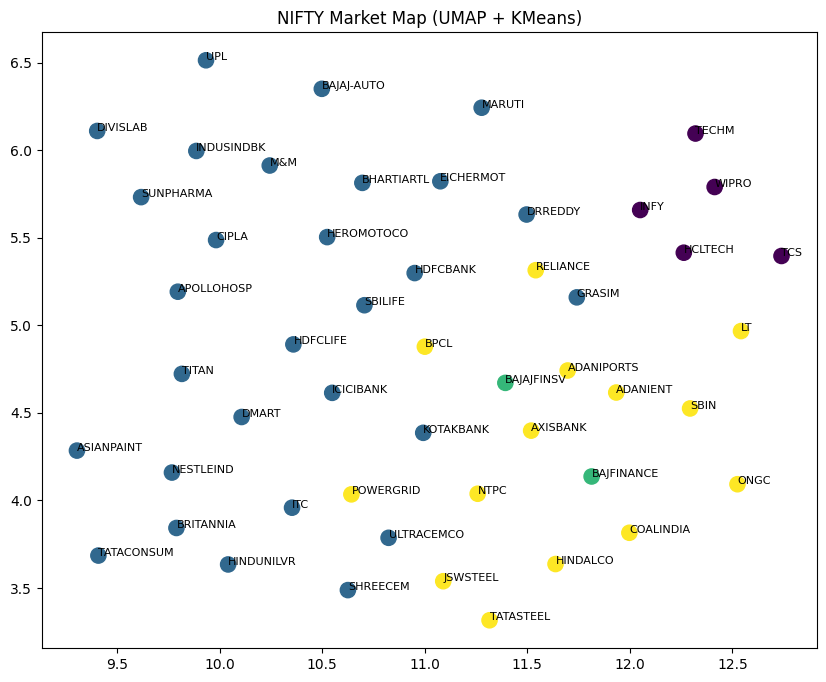

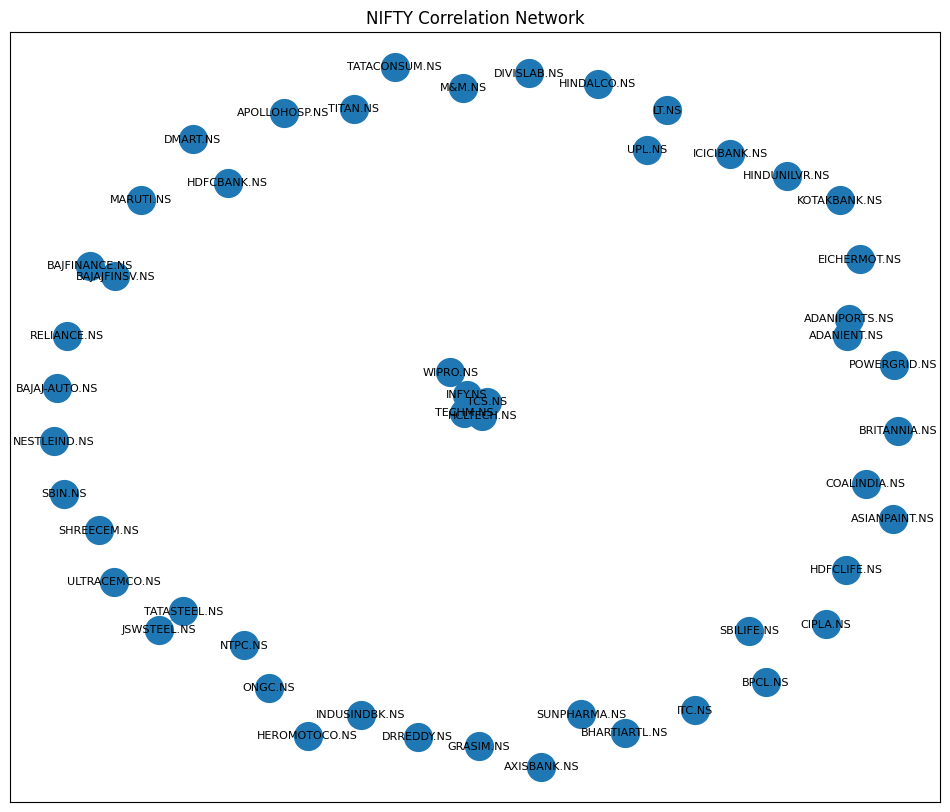

In [26]:
import yfinance as yf
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

import umap
import matplotlib.pyplot as plt
import networkx as nx

# ---------------------------------
# 1. NIFTY 50 STOCK LIST
# ---------------------------------

tickers = [
"RELIANCE.NS","TCS.NS","HDFCBANK.NS","INFY.NS","ICICIBANK.NS",
"HINDUNILVR.NS","ITC.NS","SBIN.NS","BHARTIARTL.NS","KOTAKBANK.NS",
"LT.NS","HCLTECH.NS","AXISBANK.NS","ASIANPAINT.NS","MARUTI.NS",
"SUNPHARMA.NS","TITAN.NS","ULTRACEMCO.NS","NESTLEIND.NS","BAJFINANCE.NS",
"WIPRO.NS","NTPC.NS","ONGC.NS","POWERGRID.NS","JSWSTEEL.NS",
"TATASTEEL.NS","HINDALCO.NS","TECHM.NS","ADANIENT.NS","ADANIPORTS.NS",
"BAJAJFINSV.NS","BRITANNIA.NS","DIVISLAB.NS","DRREDDY.NS","EICHERMOT.NS",
"GRASIM.NS","HEROMOTOCO.NS","INDUSINDBK.NS","SBILIFE.NS","HDFCLIFE.NS",
"COALINDIA.NS","CIPLA.NS","APOLLOHOSP.NS","BAJAJ-AUTO.NS","BPCL.NS",
"UPL.NS","TATACONSUM.NS","SHREECEM.NS","M&M.NS","DMART.NS"
]

# ---------------------------------
# 2. DOWNLOAD DATA
# ---------------------------------

prices = yf.download(
    tickers,
    period="1y"
)["Close"]

prices = prices.dropna(axis=1)

# ---------------------------------
# 3. RETURNS
# ---------------------------------

returns = prices.pct_change().dropna()

X = returns.T

# ---------------------------------
# 4. SCALE DATA
# ---------------------------------

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ---------------------------------
# 5. UMAP EMBEDDING
# ---------------------------------

umap_model = umap.UMAP(
    n_neighbors=10,
    min_dist=0.1,
    random_state=42
)

embedding = umap_model.fit_transform(X_scaled)

# ---------------------------------
# 6. KMEANS CLUSTERING
# ---------------------------------

kmeans = KMeans(n_clusters=4, random_state=42)

clusters = kmeans.fit_predict(X_scaled)

# ---------------------------------
# 7. PLOT MARKET MAP
# ---------------------------------

plt.figure(figsize=(10,8))

plt.scatter(
    embedding[:,0],
    embedding[:,1],
    c=clusters,
    s=120
)

for i, ticker in enumerate(X.index):
    plt.text(
        embedding[i,0],
        embedding[i,1],
        ticker.replace(".NS",""),
        fontsize=8
    )

plt.title("NIFTY Market Map (UMAP + KMeans)")
plt.show()

# ---------------------------------
# 8. CORRELATION NETWORK
# ---------------------------------

corr = returns.corr()

G = nx.Graph()

# add nodes
for stock in corr.columns:
    G.add_node(stock)

# add edges for high correlation
threshold = 0.7

for i in corr.columns:
    for j in corr.columns:
        if i != j and corr.loc[i,j] > threshold:
            G.add_edge(i,j,weight=corr.loc[i,j])

plt.figure(figsize=(12,10))

pos = nx.spring_layout(G)

nx.draw_networkx_nodes(
    G,
    pos,
    node_size=400
)

nx.draw_networkx_edges(
    G,
    pos,
    alpha=0.3
)

nx.draw_networkx_labels(
    G,
    pos,
    font_size=8
)

plt.title("NIFTY Correlation Network")
plt.show()

In [27]:
prices

Ticker,ADANIENT.NS,ADANIPORTS.NS,APOLLOHOSP.NS,ASIANPAINT.NS,AXISBANK.NS,BAJAJ-AUTO.NS,BAJAJFINSV.NS,BAJFINANCE.NS,BHARTIARTL.NS,BPCL.NS,...,SHREECEM.NS,SUNPHARMA.NS,TATACONSUM.NS,TATASTEEL.NS,TCS.NS,TECHM.NS,TITAN.NS,ULTRACEMCO.NS,UPL.NS,WIPRO.NS
Date,,,,,,,,,,,,,,,,,,,,,
2025-03-04,2143.737305,1052.827759,6172.045410,2109.316650,1000.944580,7152.039062,1789.428223,853.329468,1562.289429,234.576843,...,27232.851562,1551.283447,947.527466,136.164566,3414.062744,1446.400757,3039.353271,10304.780273,607.837585,267.687714
2025-03-05,2244.737305,1107.312622,6198.226562,2141.023926,1013.583801,7236.888672,1800.922607,824.780701,1604.833740,240.133377,...,28021.173828,1567.078369,949.760925,142.770508,3428.561768,1494.849121,3077.289062,10398.288086,622.156494,272.563446
2025-03-06,2251.733887,1130.698853,6257.771973,2243.467773,1033.216919,7277.801758,1844.551270,835.926941,1613.412109,248.768600,...,27927.921875,1598.322021,951.101013,147.011612,3481.289551,1461.173340,3111.735352,10427.403320,619.035095,273.328278
2025-03-07,2246.386475,1138.958740,6199.922852,2245.743164,1036.764038,7387.520996,1844.401489,835.295776,1617.180542,245.220657,...,27851.736328,1593.667725,954.972290,148.106079,3490.568848,1450.385620,3070.110596,10515.744141,624.138367,272.276642
2025-03-10,2227.196045,1137.366577,6133.595703,2254.251465,1034.965454,7200.900879,1839.453735,829.143738,1617.428467,241.156464,...,27750.669922,1595.846191,950.257263,147.607712,3469.738770,1445.040161,3017.718262,10453.835938,609.868958,268.548126
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-25,2231.699951,1528.699951,7783.000000,2416.399902,1403.000000,10097.000000,2049.300049,1021.049988,1913.400024,381.049988,...,26865.000000,1764.199951,1172.300049,214.639999,2629.300049,1361.800049,4325.000000,13041.000000,626.200012,201.919998
2026-02-26,2216.399902,1550.599976,7775.000000,2394.899902,1395.500000,10110.000000,2041.300049,1012.950012,1929.599976,386.000000,...,26745.000000,1785.699951,1159.500000,215.520004,2647.699951,1361.800049,4342.600098,12937.000000,640.450012,201.080002
2026-02-27,2161.800049,1521.000000,7821.500000,2376.199951,1383.900024,9972.500000,1993.400024,995.900024,1879.300049,385.399994,...,26075.000000,1737.000000,1141.000000,212.330002,2637.399902,1357.800049,4327.500000,12677.000000,637.400024,200.960007


In [29]:
from sklearn.metrics.pairwise import cosine_similarity

# --------------------------------
# 1. STOCK SIMILARITY MATRIX
# --------------------------------

similarity = cosine_similarity(X_scaled)

sim_df = pd.DataFrame(
    similarity,
    index=X.index,
    columns=X.index
)

# --------------------------------
# 2. FIND MOST SIMILAR PAIRS
# --------------------------------

pairs = []

for i in range(len(sim_df.columns)):
    for j in range(i+1, len(sim_df.columns)):

        stock1 = sim_df.columns[i]
        stock2 = sim_df.columns[j]

        score = sim_df.iloc[i,j]

        pairs.append((stock1, stock2, score))

pairs_df = pd.DataFrame(
    pairs,
    columns=["Stock1","Stock2","Similarity"]
)

pairs_df = pairs_df.sort_values(
    "Similarity",
    ascending=False
)

print("\nTop Opportunity Pairs:")
print(pairs_df.head(10))


Top Opportunity Pairs:
             Stock1         Stock2  Similarity
966         INFY.NS         TCS.NS    0.614545
967         INFY.NS       TECHM.NS    0.612411
971         INFY.NS       WIPRO.NS    0.598882
736      HCLTECH.NS        INFY.NS    0.593136
279   BAJAJFINSV.NS  BAJFINANCE.NS    0.591450
1210         TCS.NS       TECHM.NS    0.553717
754      HCLTECH.NS         TCS.NS    0.546311
755      HCLTECH.NS       TECHM.NS    0.505704
1218       TECHM.NS       WIPRO.NS    0.496662
0       ADANIENT.NS  ADANIPORTS.NS    0.493407


In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

import umap
import matplotlib.pyplot as plt

# -----------------------------
# 1. NIFTY 50 STOCKS
# -----------------------------

tickers = [
"RELIANCE.NS","TCS.NS","HDFCBANK.NS","INFY.NS","ICICIBANK.NS",
"HINDUNILVR.NS","ITC.NS","SBIN.NS","BHARTIARTL.NS","KOTAKBANK.NS",
"LT.NS","HCLTECH.NS","AXISBANK.NS","ASIANPAINT.NS","MARUTI.NS",
"SUNPHARMA.NS","TITAN.NS","ULTRACEMCO.NS","NESTLEIND.NS","BAJFINANCE.NS",
"WIPRO.NS","NTPC.NS","ONGC.NS","POWERGRID.NS","JSWSTEEL.NS",
"TATASTEEL.NS","HINDALCO.NS","TECHM.NS","ADANIENT.NS","ADANIPORTS.NS",
"BAJAJFINSV.NS","BRITANNIA.NS","DIVISLAB.NS","DRREDDY.NS","EICHERMOT.NS",
"GRASIM.NS","HEROMOTOCO.NS","INDUSINDBK.NS","SBILIFE.NS","HDFCLIFE.NS",
"COALINDIA.NS","CIPLA.NS","APOLLOHOSP.NS","BAJAJ-AUTO.NS","BPCL.NS",
"UPL.NS","TATACONSUM.NS","SHREECEM.NS","M&M.NS","DMART.NS"
]

# -----------------------------
# 2. DOWNLOAD DATA
# -----------------------------

prices = yf.download(
    tickers,
    period="2y",
    auto_adjust=True
)["Close"]

prices = prices.dropna(axis=1)

# -----------------------------
# 3. BUILD FACTOR FEATURES
# -----------------------------

features = []

for stock in prices.columns:

    p = prices[stock]

    ma50 = p.rolling(50).mean()
    ma200 = p.rolling(200).mean()

    momentum = p.pct_change(60).iloc[-1]
    volatility = p.pct_change().std()

    dist_ma50 = (p.iloc[-1] - ma50.iloc[-1]) / ma50.iloc[-1]
    dist_ma200 = (p.iloc[-1] - ma200.iloc[-1]) / ma200.iloc[-1]

    drawdown = (p / p.cummax() - 1).min()

    trend = ma50.iloc[-1] - ma200.iloc[-1]

    features.append([
        momentum,
        volatility,
        dist_ma50,
        dist_ma200,
        drawdown,
        trend
    ])

features_df = pd.DataFrame(
    features,
    columns=[
        "Momentum",
        "Volatility",
        "Dist_MA50",
        "Dist_MA200",
        "Drawdown",
        "Trend"
    ],
    index=prices.columns
)

# -----------------------------
# 4. SCALE FEATURES
# -----------------------------

scaler = StandardScaler()

X_scaled = scaler.fit_transform(features_df)

# -----------------------------
# 5. UMAP DIMENSION REDUCTION
# -----------------------------

umap_model = umap.UMAP(
    n_neighbors=10,
    min_dist=0.2,
    random_state=42
)

X_umap = umap_model.fit_transform(X_scaled)

               Momentum  Volatility  Dist_MA50  Dist_MA200  Drawdown  \
Ticker                                                                 
ADANIENT.NS   -0.083694    0.025247  -0.042475   -0.126531 -0.488141   
ASIANPAINT.NS -0.234630    0.013391  -0.122792   -0.097575 -0.368727   
ITC.NS        -0.212127    0.011905  -0.061785   -0.189191 -0.353237   
HCLTECH.NS    -0.180859    0.015243  -0.137309   -0.118889 -0.304275   
INFY.NS       -0.193540    0.015441  -0.153377   -0.143963 -0.343278   
WIPRO.NS      -0.229186    0.016894  -0.173422   -0.191912 -0.359715   
TECHM.NS      -0.144385    0.016111  -0.154006   -0.121114 -0.291500   
TCS.NS        -0.185444    0.013431  -0.139004   -0.160860 -0.403073   
UPL.NS        -0.197010    0.019184  -0.175002   -0.134421 -0.243124   
HINDALCO.NS    0.117279    0.018090  -0.009513    0.178514 -0.262294   
INDUSINDBK.NS  0.063728    0.022585   0.017545    0.114544 -0.589299   
JSWSTEEL.NS    0.039322    0.016056   0.006711    0.085403 -0.14

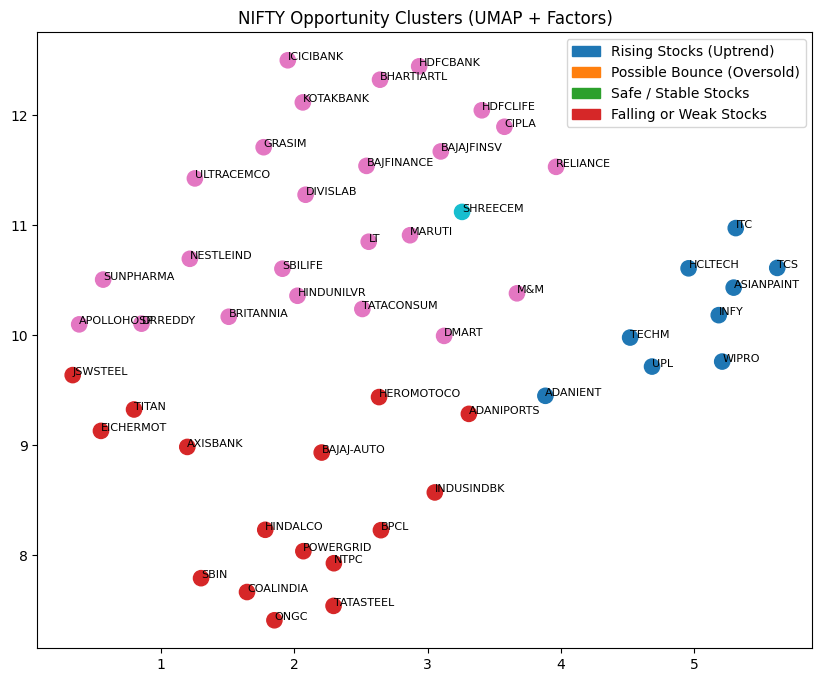

In [33]:
# -----------------------------
# 6. KMEANS CLUSTERING
# -----------------------------

kmeans = KMeans(n_clusters=4, random_state=42)

clusters = kmeans.fit_predict(X_scaled)

features_df["Cluster"] = clusters

print(features_df.sort_values("Cluster"))

centers = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=features_df.columns[:-1]
)

print(centers)
# -----------------------------
# 7. VISUALIZE OPPORTUNITY MAP
# -----------------------------

cluster_labels = {
    0: "Rising Stocks (Uptrend)",
    1: "Possible Bounce (Oversold)",
    2: "Safe / Stable Stocks",
    3: "Falling or Weak Stocks"
}
import matplotlib.patches as mpatches

plt.figure(figsize=(10,8))

scatter = plt.scatter(
    X_umap[:,0],
    X_umap[:,1],
    c=clusters,
    cmap="tab10",
    s=120
)

for i, stock in enumerate(features_df.index):
    plt.text(
        X_umap[i,0],
        X_umap[i,1],
        stock.replace(".NS",""),
        fontsize=8
    )

# create legend
handles = []

for cluster_id, label in cluster_labels.items():
    handles.append(
        mpatches.Patch(
            color=plt.cm.tab10(cluster_id),
            label=label
        )
    )

plt.legend(handles=handles)

plt.title("NIFTY Opportunity Clusters (UMAP + Factors)")
plt.show()

[*********************100%***********************]  50 of 50 completed
C:\Users\Hexi\Miniconda3\envs\dds3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(



Top Opportunity Stocks:

               Momentum  Volatility  Dist_MA50  Dist_MA200  Drawdown  \
Ticker                                                                 
MARUTI.NS     -0.132969    0.013624  -0.098842   -0.037341 -0.204437   
EICHERMOT.NS   0.059448    0.014979   0.021078    0.163721 -0.142546   
BAJAJ-AUTO.NS  0.063564    0.015827   0.011297    0.087280 -0.423135   
HEROMOTOCO.NS -0.115922    0.016004  -0.015689    0.078976 -0.421579   
TITAN.NS       0.110010    0.013836   0.022774    0.131712 -0.218884   
ULTRACEMCO.NS  0.050789    0.013633  -0.019907    0.005872 -0.161823   
LT.NS         -0.035016    0.015807  -0.040676    0.022576 -0.226269   
SBIN.NS        0.211529    0.015322   0.088679    0.285996 -0.239441   
BRITANNIA.NS  -0.007717    0.012799  -0.011418    0.015413 -0.290232   
HINDALCO.NS    0.126389    0.018073  -0.001598    0.188067 -0.262294   

                     Trend  Dist_52W_High  Cluster  OpportunityScore  
Ticker                                

C:\Users\Hexi\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128640 (\N{ROCKET}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Hexi\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Hexi\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128737 (\N{SHIELD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


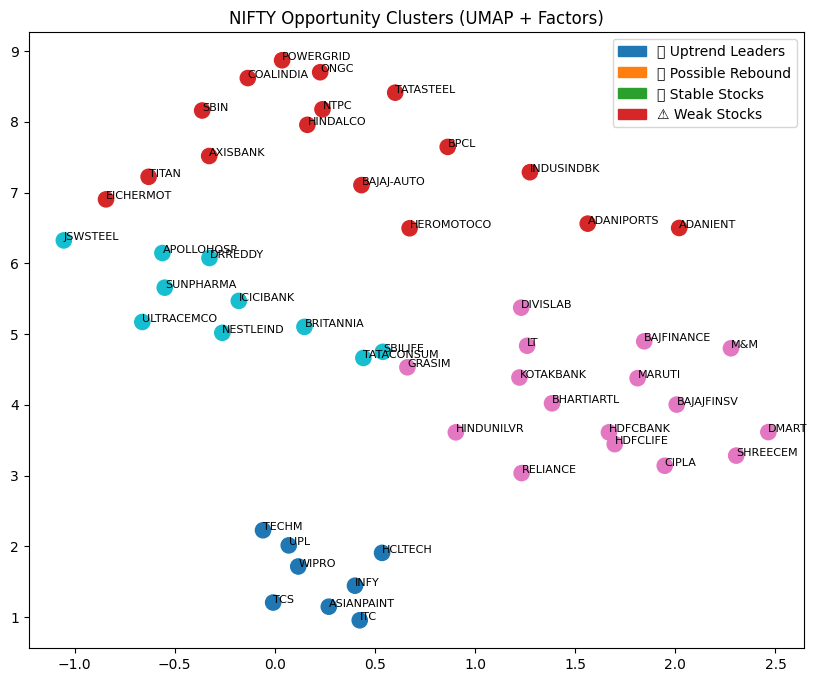

In [34]:
import yfinance as yf
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import umap
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# -----------------------------
# 1. NIFTY 50 TICKERS
# -----------------------------
tickers = [
"RELIANCE.NS","TCS.NS","HDFCBANK.NS","INFY.NS","ICICIBANK.NS",
"HINDUNILVR.NS","ITC.NS","SBIN.NS","BHARTIARTL.NS","KOTAKBANK.NS",
"LT.NS","HCLTECH.NS","AXISBANK.NS","ASIANPAINT.NS","MARUTI.NS",
"SUNPHARMA.NS","TITAN.NS","ULTRACEMCO.NS","NESTLEIND.NS","BAJFINANCE.NS",
"WIPRO.NS","NTPC.NS","ONGC.NS","POWERGRID.NS","JSWSTEEL.NS",
"TATASTEEL.NS","HINDALCO.NS","TECHM.NS","ADANIENT.NS","ADANIPORTS.NS",
"BAJAJFINSV.NS","BRITANNIA.NS","DIVISLAB.NS","DRREDDY.NS","EICHERMOT.NS",
"GRASIM.NS","HEROMOTOCO.NS","INDUSINDBK.NS","SBILIFE.NS","HDFCLIFE.NS",
"COALINDIA.NS","CIPLA.NS","APOLLOHOSP.NS","BAJAJ-AUTO.NS","BPCL.NS",
"UPL.NS","TATACONSUM.NS","SHREECEM.NS","M&M.NS","DMART.NS"
]

# -----------------------------
# 2. DOWNLOAD DATA
# -----------------------------
prices = yf.download(
    tickers,
    period="2y",
    auto_adjust=True
)["Close"]

prices = prices.dropna(axis=1)

returns = prices.pct_change()

# -----------------------------
# 3. COMPUTE FACTOR FEATURES
# -----------------------------
features = []

for stock in prices.columns:

    p = prices[stock]

    ma50 = p.rolling(50).mean()
    ma200 = p.rolling(200).mean()

    momentum = p.pct_change(60).iloc[-1]

    volatility = p.pct_change().std()

    dist_ma50 = (p.iloc[-1] - ma50.iloc[-1]) / ma50.iloc[-1]

    dist_ma200 = (p.iloc[-1] - ma200.iloc[-1]) / ma200.iloc[-1]

    drawdown = (p / p.cummax() - 1).min()

    trend = ma50.iloc[-1] - ma200.iloc[-1]

    high_52 = p.rolling(252).max().iloc[-1]

    dist_high = (p.iloc[-1] - high_52) / high_52

    features.append([
        momentum,
        volatility,
        dist_ma50,
        dist_ma200,
        drawdown,
        trend,
        dist_high
    ])

features_df = pd.DataFrame(
    features,
    columns=[
        "Momentum",
        "Volatility",
        "Dist_MA50",
        "Dist_MA200",
        "Drawdown",
        "Trend",
        "Dist_52W_High"
    ],
    index=prices.columns
)

# -----------------------------
# 4. SCALE FEATURES
# -----------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features_df)

# -----------------------------
# 5. UMAP DIMENSION REDUCTION
# -----------------------------
umap_model = umap.UMAP(
    n_neighbors=10,
    min_dist=0.2,
    random_state=42
)

X_umap = umap_model.fit_transform(X_scaled)

# -----------------------------
# 6. CLUSTER ON UMAP
# -----------------------------
kmeans = KMeans(n_clusters=4, random_state=42)

clusters = kmeans.fit_predict(X_umap)

features_df["Cluster"] = clusters

# -----------------------------
# 7. OPPORTUNITY SCORE
# -----------------------------
features_df["OpportunityScore"] = (
    0.4 * features_df["Momentum"]
    + 0.3 * features_df["Trend"]
    - 0.1 * features_df["Volatility"]
    + 0.2 * features_df["Dist_52W_High"]
)

ranking = features_df.sort_values(
    "OpportunityScore",
    ascending=False
)

print("\nTop Opportunity Stocks:\n")
print(ranking.head(10))

# -----------------------------
# 8. VISUALIZE CLUSTERS
# -----------------------------
cluster_labels = {
    0: "Uptrend Leaders",
    1: "Possible Rebound",
    2: "Stable Stocks",
    3: "Weak Stocks"
}

plt.figure(figsize=(10,8))

scatter = plt.scatter(
    X_umap[:,0],
    X_umap[:,1],
    c=clusters,
    cmap="tab10",
    s=120
)

for i, stock in enumerate(features_df.index):
    plt.text(
        X_umap[i,0],
        X_umap[i,1],
        stock.replace(".NS",""),
        fontsize=8
    )

handles = []

for cluster_id, label in cluster_labels.items():
    handles.append(
        mpatches.Patch(
            color=plt.cm.tab10(cluster_id),
            label=label
        )
    )

plt.legend(handles=handles)

plt.title("NIFTY Opportunity Clusters (UMAP + Factors)")

plt.show()